# Setting Up Environment

## Install Dependencies

In [ ]:
!conda create --file environment.yml

## Import Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud
from src.sentence_embeddings import SentenceEmbedding
from src.clustering import RecursiveSphericalKMeans

c:\Users\Najib\miniconda3\envs\ta_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [24]:
with open('datasets/preprocessed_tickets.txt', 'r', encoding='utf-8') as f:
        preprocessed_data = [line.strip() for line in f.readlines()]

print(preprocessed_data[:5])

['isu: crawlback comment. siang tim it minta tolong bantuan nya untuk crawlback comment medsos postingan dari akun. - gibran_rakabuming (instagram). - gibran_rakabuming (tiktok). - setwapres.ri (instagram). - wakil presiden republik indonesia (youtube). postingan selama periode 12 - 15 april 2026 pada dashboard medsos setwapres. terima kasih', 'selamat pagi tim it, mohon bantuannya saya menemukan link dari megapolitan.kompas.com tidak masuk dasboard. berita tersebut publis pada tanggal 14 april 2026 pukul 18;15. tadi pukul 06.30 sudah dilakukan crawlback manual juga. mohon dilakukan cek dan kenapa link tersebut tidak masuk ke dalam dasboard, karena jika melihat konten beritanya, ada keyword "pelindo". . berikut untuk link yang tidak masuknya;.  sebagai informasi, link lain dari megapolitan.kompas.com yang tanggal 15 april pukul 00:05 bisa masuk ke dalam dasboard berikut untuk link nya.', 'isu: data postingan instagram tidak masuk. selamat malam tim it, boleh dibantu untuk dicek kendala

# Sentence Embedding

## Initiate model

In [25]:
embedding_model = SentenceEmbedding('denaya/indoSBERT-large')

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 13476.64it/s]


## Embed Sentence Data

In [26]:
sentence_vectors = embedding_model.encode(preprocessed_data)

## Save Sentence Vectors

In [8]:
embedding_model.save_to_file(sentence_vectors, 'results/sentence_embeddings.npy')

# Clustering

## Load Vectors

In [2]:
sentence_vectors = np.load('results/sentence_embeddings.npy')

print(f"Sentence vectors: {sentence_vectors[:5]}")

n_sentences, dim = sentence_vectors.shape
print(f"Loaded sentence embedding dimension: {dim}, Number of sentences: {n_sentences}")

Sentence vectors: [[ 0.13135763 -0.40497142  0.04257007 ...  0.33207834 -0.3044789
   0.35353354]
 [ 0.13257943  0.06508315 -0.5534547  ...  0.05757745 -0.66382957
   0.6973722 ]
 [-0.23592697  0.10757953 -0.46797356 ...  0.20528315 -0.33531913
   0.4794609 ]
 [ 0.19074483  0.02738556 -0.07053424 ...  0.20222361 -0.22843865
   0.56214964]
 [ 0.2028788   0.03158585 -0.02052342 ...  0.22696619  0.40127838
   0.23948242]]
Loaded sentence embedding dimension: 256, Number of sentences: 1639


## Initiate Spherical K-means

In [13]:
import importlib
from src import clustering
importlib.reload(clustering)
from src.clustering import RecursiveSphericalKMeans

In [14]:
recursive_model = RecursiveSphericalKMeans(d=dim, min_k=2, max_k=10, niter=20)

## Run Clustering

In [15]:
hasil = recursive_model.fit_exhaustive(sentence_vectors)

Memulai inisialisasi dan normalisasi L2...

Memulai proses Exhaustive Recursive K-Means...

>> Level 1: k=2 (Silhouette: 0.1400)
   L2 -> Klaster Induk 0 (n=331): Optimal sub-k = 4 (Score: 0.1554)
   L2 -> Klaster Induk 1 (n=1308): Optimal sub-k = 2 (Score: 0.1679)

>> Level 1: k=3 (Silhouette: 0.1652)
   L2 -> Klaster Induk 0 (n=378): Optimal sub-k = 10 (Score: 0.1494)
   L2 -> Klaster Induk 1 (n=327): Optimal sub-k = 5 (Score: 0.1464)
   L2 -> Klaster Induk 2 (n=934): Optimal sub-k = 3 (Score: 0.0755)

>> Level 1: k=4 (Silhouette: 0.1383)
   L2 -> Klaster Induk 0 (n=423): Optimal sub-k = 2 (Score: 0.0974)
   L2 -> Klaster Induk 1 (n=305): Optimal sub-k = 3 (Score: 0.1413)
   L2 -> Klaster Induk 2 (n=316): Optimal sub-k = 2 (Score: 0.1583)
   L2 -> Klaster Induk 3 (n=595): Optimal sub-k = 2 (Score: 0.1077)

>> Level 1: k=5 (Silhouette: 0.1402)
   L2 -> Klaster Induk 0 (n=191): Optimal sub-k = 3 (Score: 0.1558)
   L2 -> Klaster Induk 1 (n=483): Optimal sub-k = 2 (Score: 0.1094)
   L2 -

## Analyze Result

In [16]:
print("Ringkasan Hasil Terbaik:")
best_k1 = max(hasil.keys(), key=lambda k: hasil[k]['level_1_score'])
print(f"Nilai k terbaik di Level 1 adalah {best_k1} dengan skor {hasil[best_k1]['level_1_score']:.4f}")

print("Rincian pemecahan klasternya di Level 2:")
for c_id, info in hasil[best_k1]['subclusters'].items():
    print(f"- Klaster {c_id} (Isi: {info['size']} data) -> Dipecah jadi {info['optimal_k']} sub-klaster.")

Ringkasan Hasil Terbaik:
Nilai k terbaik di Level 1 adalah 3 dengan skor 0.1652
Rincian pemecahan klasternya di Level 2:
- Klaster 0 (Isi: 378 data) -> Dipecah jadi 10 sub-klaster.
- Klaster 1 (Isi: 327 data) -> Dipecah jadi 5 sub-klaster.
- Klaster 2 (Isi: 934 data) -> Dipecah jadi 3 sub-klaster.


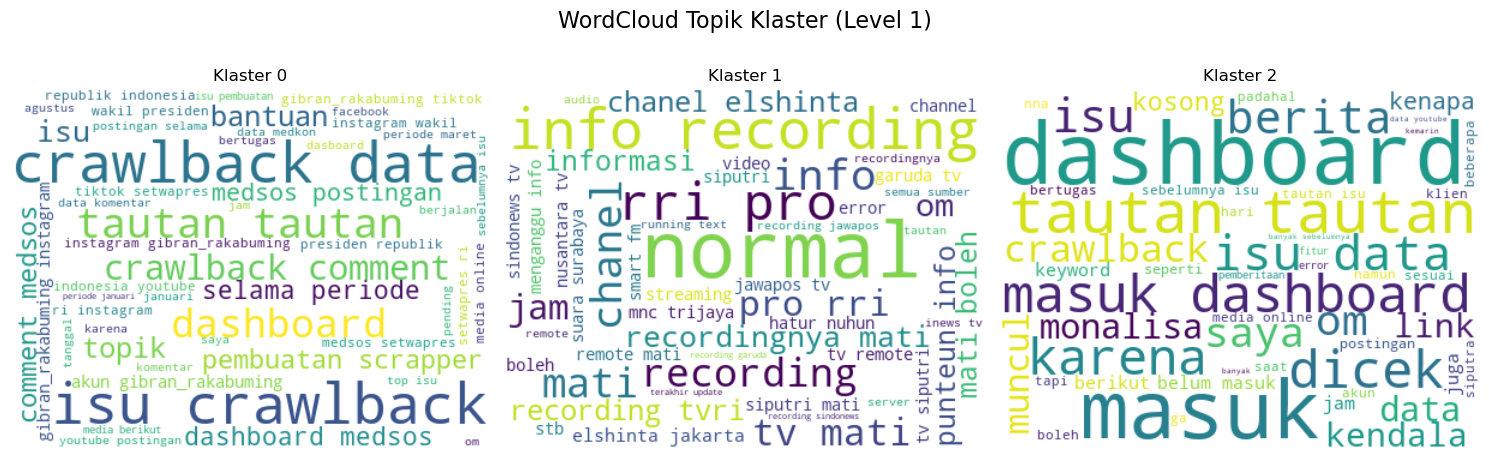

In [23]:
# 1. Asumsi kamu punya data teks asli di dalam list/array bernama 'teks_tiket'
# teks_tiket = ["Printer rusak di lantai 3", "Lupa password email", ...]

# 2. Ambil label klaster untuk k=3 dari model (Kamu harus run ulang untuk k=3 atau modifikasi class untuk mereturn labelnya)
labels_k3 = recursive_model._run_kmeans(sentence_vectors, 3)

# 3. Gabungkan semua teks untuk masing-masing klaster
teks_per_klaster = {0: "", 1: "", 2: ""}

for teks, label in zip(preprocessed_data, labels_k3):
    teks_per_klaster[label] += str(teks) + " "

# 4. Daftar Stopwords (Kata yang diabaikan)
# Tambahkan kata-kata umum IT yang mungkin mendominasi tapi tidak bermakna spesifik
daftar_stopwords = [
    "yang", "di", "dan", "ke", "dari", "untuk", "dengan", "ini", "itu", "pada",
    "terima", "kasih", "tim", "it", "selamat", "pagi", "siang", "sore", "malam",
    "bantuannya", "tolong", "mohon", "dibantu", "cek", "agar", "bisa", "tidak", 
    "ya", "yaa", "mas", "mbak", "nama", "orang", "punten", "maaf", "halo",
    "kembali", "mau", "minta", "nya", "yg", "ada", "sudah", "terimakasih", "bantu"
]

# 5. Buat Visualisasi WordCloud untuk setiap klaster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('WordCloud Topik Klaster (Level 1)', fontsize=16)

for cluster_id in range(3):
    wc = WordCloud(
        width=400, height=300, 
        background_color='white',
        stopwords=daftar_stopwords,
        colormap='viridis',
        max_words=50
    ).generate(teks_per_klaster[cluster_id])
    
    axes[cluster_id].imshow(wc, interpolation='bilinear')
    axes[cluster_id].set_title(f'Klaster {cluster_id}')
    axes[cluster_id].axis('off')

plt.tight_layout()
plt.show()

In [20]:
# 1. Asumsi data (Ganti dengan variabel aslimu)
# teks_tiket = list berisi teks tiket aslimu
# labels_k3 = array label klaster (misal dari: labels_k3 = recursive_model._run_kmeans(sentence_vectors, 3))

# Gabungkan stopwords bawaan dengan custom stopwords yang kita bahas sebelumnya
daftar_stopwords = [
    "yang", "di", "dan", "ke", "dari", "untuk", "dengan", "ini", "itu", "pada",
    "terima", "kasih", "tim", "it", "selamat", "pagi", "siang", "sore", "malam",
    "bantuannya", "tolong", "mohon", "dibantu", "cek", "agar", "bisa", "tidak", 
    "ya", "yaa", "mas", "mbak", "nama", "orang", "punten", "maaf", "halo",
    "kembali", "mau", "minta", "nya", "yg", "ada", "sudah"
]

# 2. Inisiasi TfidfVectorizer
# max_df=0.85 berarti abaikan kata yang muncul di >85% total tiket (otomatis filter noise)
vectorizer = TfidfVectorizer(stop_words=daftar_stopwords, max_df=0.85, min_df=2)

# Fit dan transform seluruh teks menjadi matriks TF-IDF
print("Menghitung bobot TF-IDF...")
tfidf_matrix = vectorizer.fit_transform(preprocessed_data)
feature_names = vectorizer.get_feature_names_out()

# 3. Ekstrak Kata Kunci untuk Tiap Klaster
top_n = 10  # Jumlah kata kunci yang ingin ditampilkan per klaster
hasil_topik = {}

for cluster_id in range(3): # Sesuaikan dengan jumlah k di level 1 (yaitu 3)
    # Cari indeks tiket mana saja yang masuk ke klaster ini
    idx = np.where(labels_k3 == cluster_id)[0]
    
    # Ambil subset matriks TF-IDF hanya untuk tiket di klaster ini
    cluster_tfidf = tfidf_matrix[idx]
    
    # Hitung nilai rata-rata TF-IDF untuk setiap kata khusus di klaster ini
    mean_tfidf = np.asarray(cluster_tfidf.mean(axis=0)).flatten()
    
    # Urutkan dan ambil top_n kata dengan nilai rata-rata tertinggi
    top_indices = mean_tfidf.argsort()[-top_n:][::-1]
    top_words = [(feature_names[i], mean_tfidf[i]) for i in top_indices]
    
    hasil_topik[cluster_id] = top_words

# 4. Tampilkan Hasilnya dengan Rapih
print("\n=== HASIL EKSTRAKSI TOPIK TF-IDF ===")
for cluster_id, words in hasil_topik.items():
    print(f"\nKlaster {cluster_id} (Jumlah Tiket: {len(np.where(labels_k3 == cluster_id)[0])})")
    print("-" * 40)
    # Format agar tampil rapih dalam bentuk tabel sederhana
    for word, score in words:
        print(f"{word:<20} | Bobot: {score:.4f}")

Menghitung bobot TF-IDF...

=== HASIL EKSTRAKSI TOPIK TF-IDF ===

Klaster 0 (Jumlah Tiket: 389)
----------------------------------------
crawlback            | Bobot: 0.1406
data                 | Bobot: 0.0974
isu                  | Bobot: 0.0800
medsos               | Bobot: 0.0539
periode              | Bobot: 0.0525
media                | Bobot: 0.0457
2026                 | Bobot: 0.0422
comment              | Bobot: 0.0378
sna                  | Bobot: 0.0353
dashboard            | Bobot: 0.0351

Klaster 1 (Jumlah Tiket: 327)
----------------------------------------
recording            | Bobot: 0.1600
mati                 | Bobot: 0.1525
info                 | Bobot: 0.1410
tv                   | Bobot: 0.1104
bantu                | Bobot: 0.1043
normal               | Bobot: 0.0869
terimakasih          | Bobot: 0.0784
chanel               | Bobot: 0.0701
tvri                 | Bobot: 0.0511
fm                   | Bobot: 0.0495

Klaster 2 (Jumlah Tiket: 923)
--------------------